In [1]:
# loading the data
from sklearn.datasets import fetch_openml
mnist = fetch_openml("mnist_784", version=1, as_frame=False, parser="auto")
X = mnist.data
y = mnist.target

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [3]:
X = pd.DataFrame(X)
X

,0,1,2,3,4,5,6,7,8,9,...,774,775,776,777,778,779,780,781,782,783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
69996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
69997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
69998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


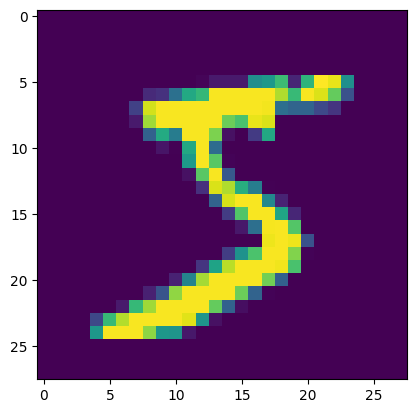

In [4]:
plt.imshow(X.iloc[0,:].values.reshape(28,28))

# Fitting the model with out PCA

In [5]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state = 42)

In [6]:
X_test.shape

(14000, 784)

In [7]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [8]:
knn = KNeighborsClassifier()
knn.fit(X_train,y_train)
y_pred = knn.predict(X_test)
accuracy_score(y_test,y_pred)

0.9700714285714286

# Fitting the model after PCA

In [9]:
# Scaling the values
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

In [10]:
from sklearn.decomposition import PCA
pca = PCA(n_components=5)

In [11]:
# in this step, we are fitting the pca. thus that calculates the eigen vectors and eigen values,
# and shifts the data to the new coordiante axes.
X_train_tfr = pca.fit_transform(X_train)
X_test_tfr = pca.transform (X_test)

In [12]:
X_test_tfr.shape

(14000, 5)

In [13]:
knn = KNeighborsClassifier()
knn.fit(X_train_tfr,y_train)
y_pred2 = knn.predict(X_test_tfr)
accuracy_score(y_test,y_pred2)

0.7385

# how do we find the optimal number of PCA components such that it explains above 90% of the variance in the original data.

In [14]:
# lets check the variance 
for i in range(1,30):
    pca = PCA(n_components=i)
    X_train_tfr = pca.fit_transform(X_train)
    X_test_tfr = pca.transform (X_test)
    knn = KNeighborsClassifier()
    knn.fit(X_train_tfr,y_train)
    y_pred2 = knn.predict(X_test_tfr)
    print(f"with {i} component", accuracy_score(y_test,y_pred2)) 

with 1 component 0.25642857142857145
with 2 component 0.32107142857142856
with 3 component 0.5111428571428571
with 4 component 0.6697142857142857
with 5 component 0.7385
with 6 component 0.8270714285714286
with 7 component 0.8442142857142857
with 8 component 0.8766428571428572
with 9 component 0.8907142857142857
with 10 component 0.9115
with 11 component 0.9192142857142858
with 12 component 0.924
with 13 component 0.9306428571428571
with 14 component 0.9371428571428572
with 15 component 0.9414285714285714
with 16 component 0.9436428571428571
with 17 component 0.9441428571428572
with 18 component 0.9450714285714286
with 19 component 0.9486428571428571
with 20 component 0.9484285714285714
with 21 component 0.9495714285714286
with 22 component 0.9496428571428571
with 23 component 0.9509285714285715
with 24 component 0.9505714285714286
with 25 component 0.9507142857142857
with 26 component 0.9508571428571428
with 27 component 0.9523571428571429
with 28 component 0.9529285714285715
with 29 

### we can see by only using 30 components out of 784 components,we still are able to get above 95% accuracy. this is the primary benefit of pca

# PCA can also be used to visualize high dimensional data.

In [18]:
pca = PCA(n_components=2)
X_train_tfr = pca.fit_transform(X_train)
X_test_tfr = pca.transform(X_test)

In [35]:
# plotting it in a 2D Coordinate System

import plotly.express as px

y_train_tfr = y_train.astype(str)
fig = px.scatter(
    x=X_train_tfr[:, 0],
    y=X_train_tfr[:, 1],
    color=y_train_tfr,
    labels={"x": "Principal Component 1", "y": "Principal Component 2"},
    color_discrete_sequence=px.colors.qualitative.G10
)
fig.show(renderer="vscode")

In [48]:
# plotting it in a 3D coordinate system
pca = PCA(n_components=3)
X_train_tfr = pca.fit_transform(X_train)
pca.transform(X_test)

fig = px.scatter_3d(
    x=X_train_tfr[:,0],
    y=X_train_tfr[:,1],
    z=X_train_tfr[:,2],
    color=y_train_tfr,
    labels = {"x": "Principal Component 1", "y": "Principal Component 2","z":"Principal Component 3"},
    color_discrete_sequence = px.colors.qualitative.G10_r,

)
fig.update_layout(
    margin = dict(l=50,r=50,t=50,b=50))
fig.show(renderer='vscode')

In [63]:
# Eigen vectors
print(pca.components_) # these are the 3 eigen vectors ( or principal components) in order which PCA has calculated 
#                                           such that they are top 3 eigen vectors which  individually explains the maximum variance of the original data.
pca.components_.shape # gives the shape of total prinicapl components.

[[ 0.  0.  0. ...  0.  0.  0.]
 [-0. -0. -0. ... -0. -0. -0.]
 [ 0.  0.  0. ...  0.  0.  0.]]


(3, 784)

In [ ]:
# explained variance represents the lambda of the principal components we have taken when fitting PCA. its shape is obviously same as the no of components chosen in PCA.
# individually, each lambda represents the amount of variance explained by that specific principal component in the original data.
pca.explained_variance_ # returns 3 value which are the also the lambda or eigen values of the eigen vectors(principal components).

array([40.6329685 , 29.01311301, 26.91849535])

In [59]:
# lests see the amount of variance expained by each of the principal  in the original data
print(pca.explained_variance_ratio_ *100 )# multiplying by 100, this returns the percentage of variance explained by each PC of the original dataset

print("total variance explained by the three Principal compontents  = ",(pca.explained_variance_ratio_*100).sum()) 
# it explains only 13% variance of the orignal data, which is too low,so we add principal components until the cumulative sum of the variance explained  is above 90% or a certain thereshold.

[5.67489426 4.0520384  3.75949926]
total variance explained by the three Principal compontents  =  13.486431913889481


# we can also determine intuitively optimium number of components we must take,by plotting a graph of explained variance ratio.

In [64]:
pca = PCA(n_components=None)
pca.fit_transform(X_train)

array([[-6.61846629e-01, -3.52844877e+00,  3.59270247e+00, ...,
         2.35492331e-15,  2.68858736e-15,  5.54306915e-15],
       [-2.42562490e+00, -3.51506096e+00, -6.09394423e+00, ...,
         1.04138132e-14, -7.46762874e-15, -1.75212774e-14],
       [-3.56713340e+00,  4.78236184e+00, -1.52162503e-01, ...,
         2.32658442e-14,  4.15042112e-16, -1.64635439e-14],
       ...,
       [-8.34347904e+00, -1.19630488e+00,  2.03380685e+00, ...,
         3.99886168e-15, -1.82009006e-14,  6.17169751e-15],
       [ 1.04937875e+01, -9.03606709e+00, -2.05320220e+00, ...,
         9.07334341e-15, -3.21066810e-15, -2.75973396e-14],
       [ 1.05730275e+01, -1.23176492e+01,  3.06175533e+00, ...,
         3.16383542e-14, -8.80901859e-15, -2.69710742e-14]])

In [67]:
pca.components_.shape

(784, 784)

In [68]:
pca.explained_variance_ratio_.shape

(784,)

In [70]:
np.cumsum(pca.explained_variance_ratio_)

array([0.05674894, 0.09726933, 0.13486432, 0.16394266, 0.18922822,
       0.2112008 , 0.23034992, 0.24791485, 0.26323209, 0.27717496,
       0.29064362, 0.30274463, 0.31395047, 0.32494179, 0.33525705,
       0.34523224, 0.35461032, 0.36383165, 0.37276159, 0.38140025,
       0.38962348, 0.39763208, 0.40530461, 0.41275343, 0.4199253 ,
       0.42684165, 0.43363123, 0.44023178, 0.44655255, 0.45267144,
       0.45868955, 0.46459041, 0.47026563, 0.4758571 , 0.48140571,
       0.4867798 , 0.4920408 , 0.49724346, 0.50237036, 0.50721194,
       0.51199592, 0.51667851, 0.5212608 , 0.52580576, 0.53028051,
       0.5346804 , 0.53906093, 0.54337629, 0.54763368, 0.55181705,
       0.55593261, 0.5599607 , 0.56395699, 0.56790803, 0.57180668,
       0.57555611, 0.57927153, 0.58297237, 0.58659865, 0.59018836,
       0.59372061, 0.59720922, 0.60065098, 0.60407883, 0.6074625 ,
       0.61078319, 0.61407195, 0.61730706, 0.62049057, 0.62365472,
       0.62677964, 0.62988218, 0.6329545 , 0.63598082, 0.63897

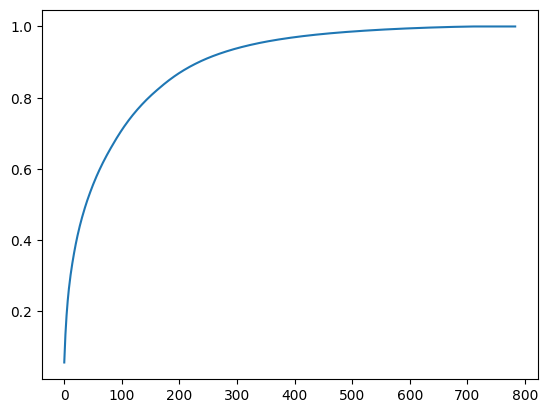

In [71]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))

In [72]:
# we can approximately determine the number of principal components we should take such that they explain above 90% variance of the original data.